In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [6]:
# Step 1: Load the dataset
file_path = 'bank-additional-full.csv'

data = pd.read_csv(file_path, sep=';')  # Assuming the delimiter is ';'

In [7]:
# Step 2: Inspect the data
print("Dataset Shape:", data.shape)
print("First 5 Rows:\n", data.head())
print("Data Types:\n", data.dtypes)


Dataset Shape: (41188, 21)
First 5 Rows:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.

In [8]:
# Step 3: Preprocessing
# Convert target variable to binary (assuming 'y' is the target column)
data['y'] = data['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [9]:
# Encode categorical features
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    if column != 'y':
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

In [10]:
# Separate features and target
X = data.drop('y', axis=1)
y = data['y']



In [11]:
# Standardize numerical features (optional, based on the dataset)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

In [12]:
# Step 4: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Step 5: Build the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)




DecisionTreeClassifier(random_state=42)

In [15]:
# Step 6: Evaluate the Model
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8888079630978393
Confusion Matrix:
 [[6847  456]
 [ 460  475]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      7303
           1       0.51      0.51      0.51       935

    accuracy                           0.89      8238
   macro avg       0.72      0.72      0.72      8238
weighted avg       0.89      0.89      0.89      8238



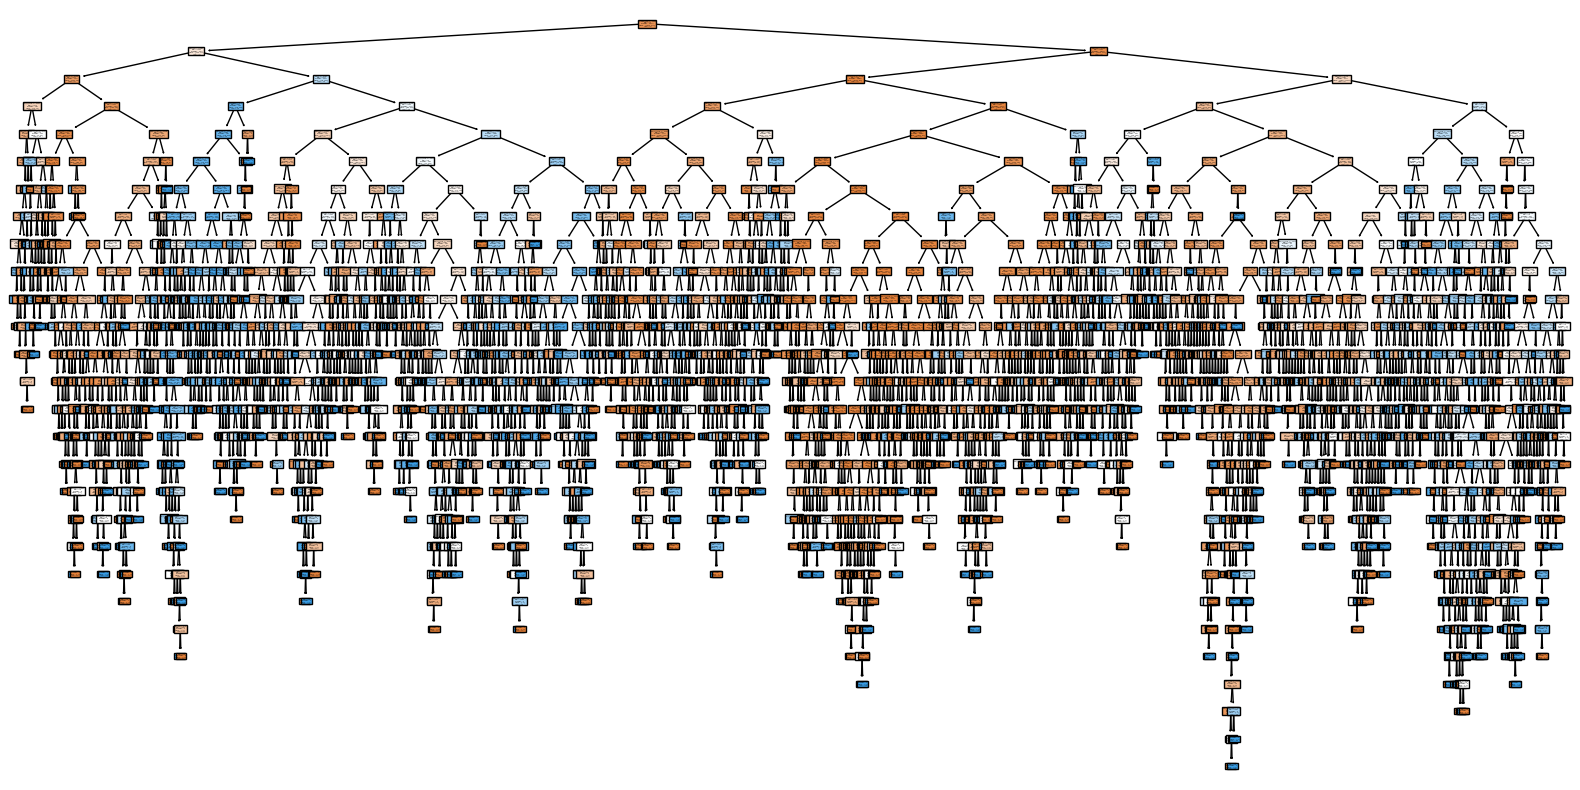

In [16]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.show()

In [17]:
# Save the Model
import joblib
joblib.dump(clf, 'decision_tree_model.pkl')




['decision_tree_model.pkl']

In [18]:
# Save the preprocessing objects
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

['label_encoders.pkl']